# Parte 1: Análise Exploratória com APIs Externas

In [ ]:
### Instalações

In [ ]:
!pip install plotly scikit-learn
!pip install folium

### Bibliotecas

In [201]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [202]:
# Geral
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path

# Visualização
import matplotlib.pyplot as plt
import plotly.express as px

# Pré-processamento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelagem
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [203]:
import importlib
import notebooks.funcao_aux as fc
importlib.reload(fc)

<module 'notebooks.funcao_aux' from 'C:\\Users\\quezi\\prefeitura2026\\desafio-cientista-dados-senior-cidadaos-vulneraveis\\notebooks\\funcao_aux.py'>

### Constantes e variáveis

In [204]:
BASE_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(BASE_DIR)

db_path = os.path.join(BASE_DIR, "dev.duckdb")


In [215]:
db_path

'C:\\Users\\quezi\\prefeitura2026\\desafio-cientista-dados-senior-cidadaos-vulneraveis\\dev.duckdb'

### Conexões

In [205]:
profiles_path = Path.home() / ".dbt" / "profiles.yml"
profiles_path.parent.mkdir(exist_ok=True)

profiles_path.write_text("""
cidadaos_vulneraveis:
  target: dev
  outputs:
    dev:
      type: duckdb
      path: dev.duckdb
""", encoding="utf-8")

99

In [206]:
%cd {BASE_DIR}

!dbt debug

C:\Users\quezi\prefeitura2026\desafio-cientista-dados-senior-cidadaos-vulneraveis
05:13:02  Running with dbt=1.11.8
05:13:02  dbt version: 1.11.8
05:13:02  python version: 3.13.9
05:13:02  python path: C:\Users\quezi\anaconda3\python.exe
05:13:02  os info: Windows-11-10.0.26200-SP0
05:13:02  Using profiles dir at C:\Users\quezi\.dbt
05:13:02  Using profiles.yml file at C:\Users\quezi\.dbt\profiles.yml
05:13:02  Using dbt_project.yml file at C:\Users\quezi\prefeitura2026\desafio-cientista-dados-senior-cidadaos-vulneraveis\dbt_project.yml
05:13:02  adapter type: duckdb
05:13:02  adapter version: 1.10.1
05:13:02  Configuration:
05:13:02    profiles.yml file [OK found and valid]
05:13:02    dbt_project.yml file [OK found and valid]
05:13:02  Required dependencies:
05:13:02   - git [OK found]

05:13:02  Connection:
05:13:02    database: dev
05:13:02    schema: main
05:13:02    path: dev.duckdb
05:13:02    config_options: None
05:13:02    extensions: None
05:13:02    settings: {}
05:13:02   

In [207]:
!dbt run --select staging
!dbt run --select intermediate

05:13:13  Running with dbt=1.11.8
05:13:14  Registered adapter: duckdb=1.10.1
05:13:14  [WARNING]: Configuration paths exist in your dbt_project.yml file which do not apply to any resources.
There are 1 unused configuration paths:
- models.cidadaos_vulneraveis.marts
05:13:15  Found 3 models, 14 data tests, 475 macros
05:13:15  
05:13:15  Concurrency: 1 threads (target='dev')
05:13:15  
05:13:15  1 of 2 START sql table model main.stg_chamado_1746 ............................. [RUN]
05:13:41  1 of 2 OK created sql table model main.stg_chamado_1746 ........................ [OK in 26.24s]
05:13:41  2 of 2 START sql table model main.stg_dim_territorio ........................... [RUN]
05:13:42  2 of 2 OK created sql table model main.stg_dim_territorio ...................... [OK in 0.15s]
05:13:42  
05:13:42  Finished running 2 table models in 0 hours 0 minutes and 26.78 seconds (26.78s).
05:13:42  
05:13:42  Completed successfully
05:13:42  
05:13:42  Done. PASS=2 WARN=0 ERROR=0 SKIP=0 NO-O

In [212]:
con = duckdb.connect(db_path)
# conecta no banco do dbt
con = duckdb.connect("dev.duckdb")

In [214]:
## Executar para fechar a conexão duckdb
con.close()

## 1. Clima e Demanda de Serviços

In [213]:
df_chamado = con.execute("""
select * 
from int_chamado_agrupado
""").fetchdf()
df_chamado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809055 entries, 0 to 809054
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   data_particao             809055 non-null  datetime64[us]
 1   tipo                      809055 non-null  object        
 2   id_bairro                 809055 non-null  object        
 3   id_regiao_administrativa  809055 non-null  object        
 4   volume_chamados           809055 non-null  int64         
dtypes: datetime64[us](1), int64(1), object(3)
memory usage: 30.9+ MB


In [ ]:
# Trabalhando com a região central do Rio
df_clima = fc.buscar_clima_historico(
    latitude=-22.90,
    longitude=-43.20,
    data_inicio="2023-01-01",
    data_fim="2024-12-31"
)

df_clima.head()

,data_particao,temperatura,precipitacao,latitude,longitude
0,2023-01-01,24.8,2.8,-22.9,-43.2
1,2023-01-02,25.8,0.0,-22.9,-43.2
2,2023-01-03,27.6,2.0,-22.9,-43.2
3,2023-01-04,27.3,14.4,-22.9,-43.2
4,2023-01-05,23.2,14.3,-22.9,-43.2


In [89]:
# merge entre a os chamaos e a base de clima
df_chamado["data_particao"] = pd.to_datetime(df_chamado["data_particao"])
df_final = df_chamado.merge(
    df_clima,
    on="data_particao",
    how="left")

# agregação
df_analise = (
    df_final
    .groupby(["data_particao", "tipo"])
    .agg(volume_chamados=("volume_chamados", "sum"),
         temperatura=("temperatura", "mean"),
         precipitacao=("precipitacao", "mean"))
    .reset_index())

# Correlação
df_corr = (
    df_analise
    .groupby("tipo")
    .apply(lambda x: pd.Series({
        "corr_temperatura": x["volume_chamados"].corr(x["temperatura"]),
        "corr_precipitacao": x["volume_chamados"].corr(x["precipitacao"]),
        "total_chamados": x["volume_chamados"].sum()
    }))
    .reset_index()
)

c:\Users\quezi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\quezi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\quezi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\quezi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\quezi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\quezi\AppData\Local\Temp\ipykernel_8652\3535997876.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future 

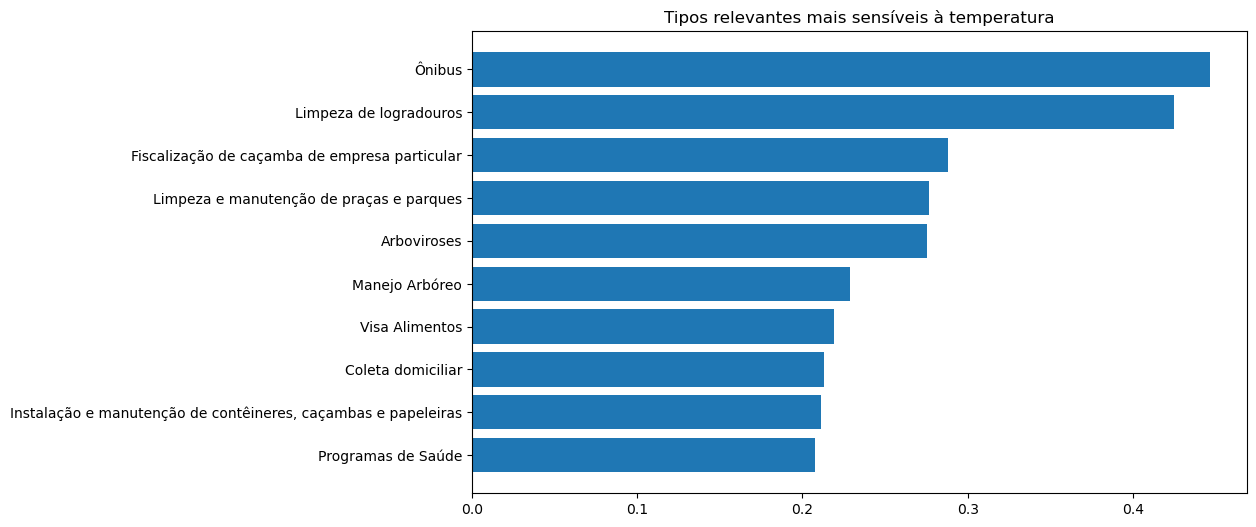

In [64]:
# Temperatura vs volume

# retirando casos de baixo volume
df_corr_filtrado_temp = df_corr[df_corr["total_chamados"] > 5000]

df_plot_temp = (
    df_corr_filtrado_temp
    .sort_values("corr_temperatura", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(df_plot_temp["tipo"], df_plot_temp["corr_temperatura"])
plt.gca().invert_yaxis()
plt.title("Tipos relevantes mais sensíveis à temperatura")
plt.show()

Analisando o gráfico Tipos relevantes mais sensíveis à temperatura nota-se que existe uma relação clara, embora moderada, entre dias mais quentes e o aumento da demanda por determinados serviços urbanos. Ao observar os tipos mais relevantes — ou seja, aqueles com maior volume de registros — nota-se que categorias como ônibus, limpeza de logradouros e serviços de manutenção urbana (como manejo arbóreo e conservação de espaços públicos) tendem a apresentar mais chamados conforme a temperatura aumenta.
Esse comportamento pode ser explicado de forma bastante intuitiva. Em dias mais quentes, há maior circulação de pessoas pela cidade e maior uso do espaço urbano. Com mais gente nas ruas, cresce a utilização do transporte público, o que naturalmente aumenta o volume de registros relacionados ao serviço de ônibus. Além disso, em períodos de calor intenso, é plausível que ocorram mais reclamações relacionadas ao conforto térmico nos veículos, como falhas ou insuficiência do ar-condicionado, o que contribui para o aumento da demanda nesse tipo de chamado.
Da mesma forma, o aumento da atividade urbana tende a gerar mais resíduos e maior desgaste dos espaços públicos, elevando a necessidade de serviços como limpeza de logradouros e manutenção de áreas comuns. O calor também pode intensificar determinadas condições ambientais, exigindo maior atuação em serviços como manejo arbóreo e conservação urbana.
Outro ponto relevante é que o aumento da temperatura pode alterar o comportamento da população, incentivando maior permanência em espaços públicos e ampliando a interação com a infraestrutura da cidade, o que também contribui para o crescimento da demanda por serviços.
No entanto, é importante destacar que as correlações observadas são moderadas, o que indica que a temperatura influencia o volume de chamados, mas não é o único fator determinante. Aspectos operacionais, comportamento da população e eventos específicos também exercem influência significativa.
De forma geral, os resultados mostram que o clima, especialmente a temperatura, atua como um fator complementar na explicação da demanda por serviços urbanos, sendo particularmente relevante em áreas relacionadas à mobilidade e à manutenção da cidade.

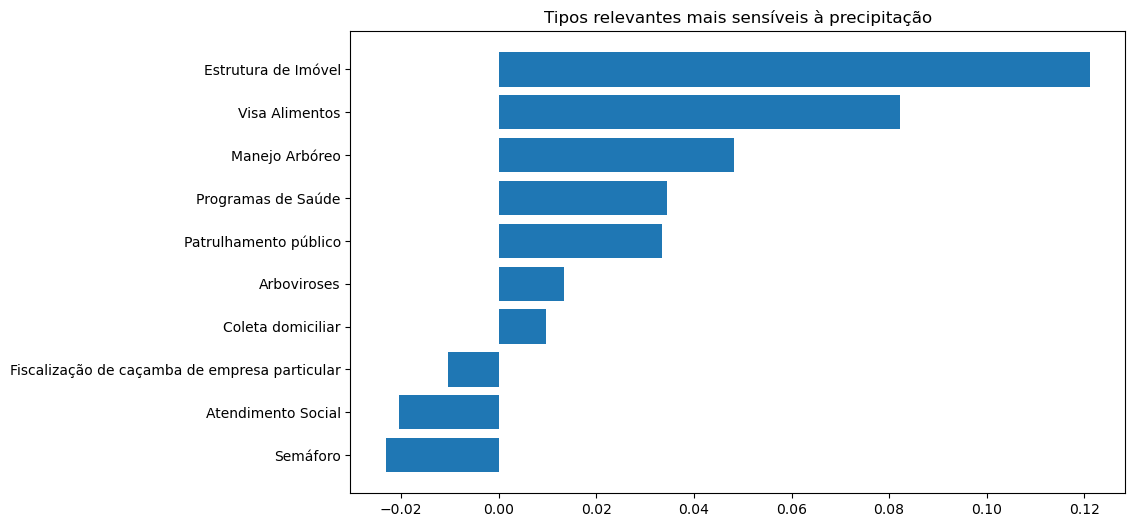

In [65]:
# Precipitação vs volume

# retirando casos de baixo volume
df_corr_filtrado_precip = df_corr[df_corr["total_chamados"] > 5000]

df_plot_precip = (
    df_corr_filtrado_precip
    .sort_values("corr_precipitacao", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(df_plot_precip["tipo"], df_plot_precip["corr_precipitacao"])
plt.gca().invert_yaxis()
plt.title("Tipos relevantes mais sensíveis à precipitação")
plt.show()

Em continuidade à análise das condições climáticas e diferentes tipos de chamados, a relação com a precipitação indica que o impacto da chuva sobre a demanda por serviços urbanos existe, mas é mais sutil e específico quando comparado à temperatura. Ao observar os tipos mais relevantes, nota-se que alguns serviços apresentam leve aumento de chamados em dias chuvosos, enquanto outros tendem a reduzir.
Entre os tipos que apresentam correlação positiva com a precipitação, destacam-se chamados relacionados à estrutura urbana e ao meio ambiente, como estrutura de imóvel, manejo arbóreo e arborização. Esse comportamento é esperado, já que períodos de chuva podem expor fragilidades em edificações, causar infiltrações, quedas de árvores ou necessidade de manutenção em áreas verdes, aumentando a demanda por esse tipo de serviço.
Além disso, serviços como vigilância sanitária (Visa Alimentos) e programas de saúde também apresentam relação positiva com a chuva, o que pode estar associado a riscos sanitários ampliados em períodos chuvosos, como acúmulo de água, aumento de vetores e necessidade de fiscalização.
Por outro lado, alguns tipos de chamados apresentam correlação negativa, como semáforo, atendimento social e fiscalização urbana. Isso pode ser explicado pela redução da circulação de pessoas em dias de chuva, o que diminui a ocorrência de situações que gerariam esse tipo de demanda.
De forma geral, a precipitação parece atuar mais como um fator que altera o padrão de comportamento da população e expõe fragilidades específicas da infraestrutura urbana, do que como um impulsionador direto e amplo da demanda por serviços. Assim como observado na análise de temperatura, as correlações são baixas, indicando que a chuva influencia o volume de chamados, mas não é o principal determinante, coexistindo com fatores operacionais e comportamentais.
Em suma, enquanto a temperatura está mais associada ao aumento geral da atividade urbana, a precipitação tende a gerar impactos mais pontuais, concentrados em áreas relacionadas à infraestrutura e ao meio ambiente.


In [66]:
print("Top 10 chamados mais recorrentes")
top_tipos = df_corr.nlargest(10, "total_chamados")
top_tipos

Top 10 chamados mais recorrentes


,tipo,corr_temperatura,corr_precipitacao,total_chamados
139,Estacionamento irregular,0.104951,-0.232517,303477.0
376,Remoção Gratuita,0.124295,-0.081136,226763.0
175,Iluminação Pública,0.081001,-0.113452,207543.0
231,Limpeza de logradouros,0.424977,-0.033603,151814.0
314,Pavimentação,-0.030984,-0.085189,148838.0
121,Drenagem e Saneamento,-0.062002,-0.049492,126314.0
238,Manejo Arbóreo,0.228829,0.048227,90352.0
436,Ônibus,0.446477,-0.043320,68267.0
319,Perturbação do sossego,-0.247795,-0.087347,48667.0
76,Controle de roedores e caramujos,0.086102,-0.063777,42129.0


A tabela de apoio, Top 10 chamados mais recorrentes, reforça os resultados observados nos gráficos, evidenciando que os tipos com maior volume de chamados apresentam, em geral, correlações moderadas com as variáveis climáticas. Destacam-se serviços como limpeza urbana e transporte (ônibus), que combinam alta representatividade com maior sensibilidade à temperatura. Por outro lado, a maioria dos tipos apresenta correlação negativa com a precipitação, indicando redução da demanda em dias chuvosos. Esses resultados confirmam que o impacto do clima varia conforme a natureza do serviço, sendo mais relevante em atividades diretamente relacionadas ao uso do espaço urbano.

## 2. Padrões Geoespaciais de Demanda

In [91]:
df_chamado.head()


,data_particao,tipo,id_bairro,id_regiao_administrativa,volume_chamados
0,2024-06-14,Pavimentação,12,7,13
1,2024-06-26,Vias públicas,29,6,2
2,2024-06-21,Pavimentação,79,15,11
3,2024-06-28,Pavimentação,139,33,10
4,2024-06-11,Drenagem e Saneamento,140,17,4


In [92]:
df_geo = con.execute("""
    SELECT
        id_bairro,
        nome_bairro,
        id_regiao_administrativa,
        nome_regiao_administrativa,
        id_area_planejamento,
        nome_regiao_planejamento,
        lat_bairro,
        lon_bairro
    FROM stg_dim_territorio
""").fetchdf()

In [94]:
df_geoanalise = df_chamado.merge(
    df_geo,
    on="id_bairro",
    how="left")
df_geoanalise[["lat_bairro", "lon_bairro"]].isna().sum()

lat_bairro    0
lon_bairro    0
dtype: int64

In [104]:
df_geoanalise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809055 entries, 0 to 809054
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   data_particao               809055 non-null  datetime64[us]
 1   tipo                        809055 non-null  object        
 2   id_bairro                   809055 non-null  object        
 3   id_regiao_administrativa_x  809055 non-null  object        
 4   volume_chamados             809055 non-null  int64         
 5   nome_bairro                 809055 non-null  object        
 6   id_regiao_administrativa_y  809055 non-null  object        
 7   nome_regiao_administrativa  809055 non-null  object        
 8   id_area_planejamento        809055 non-null  object        
 9   nome_regiao_planejamento    809055 non-null  object        
 10  lat_bairro                  809055 non-null  float64       
 11  lon_bairro                  809055 non-

### Análise
i. Ranking - volume de chamados por bairro
ii. Distribuição geoespacial dos chamados 1746 por bairro

A tabela apresenta o ranking de volume de chamados por bairro, destacando que Campo Grande, Tijuca e Bangu concentram as maiores quantidades. Já o mapa geoespacial complementa essa análise ao mostrar a localização desses bairros, evidenciando que a demanda não está distribuída de forma homogênea na cidade, com maior concentração na Zona Oeste e pontos relevantes na Zona Norte e Sul.

In [125]:
# Volume total por bairro
df_bairro = (
    df_geoanalise
    .groupby(["id_bairro", "nome_bairro", "lat_bairro", "lon_bairro"], as_index=False)
    .agg(volume_total=("volume_chamados", "sum"))
    .sort_values("volume_total", ascending=False)
)

print('Ranking - volume de chamados por bairro')
df_bairro.head(10)

Ranking - volume de chamados por bairro


,id_bairro,nome_bairro,lat_bairro,lon_bairro,volume_total
50,144,Campo Grande,-22.891790,-43.552852,141365
90,33,Tijuca,-22.933006,-43.238720,64997
47,141,Bangu,-22.858473,-43.485283,54380
32,128,Barra da Tijuca,-22.999320,-43.372447,53961
55,149,Santa Cruz,-22.916482,-43.706410,51688
80,24,Copacabana,-22.970557,-43.187459,51357
108,5,Centro,-22.906774,-43.178708,47065
44,139,Realengo,-22.881015,-43.433754,47010
58,151,Guaratiba,-22.991902,-43.590953,42452
26,122,Taquara,-22.921770,-43.384576,39913


In [126]:
# Concentração territorial
fig = px.scatter_map(
    df_bairro,
    lat="lat_bairro",
    lon="lon_bairro",
    size="volume_total",
    hover_name="nome_bairro",
    hover_data={"volume_total": True, "lat_bairro": False, "lon_bairro": False},
    zoom=10,
    height=600,
    title="Distribuição geoespacial dos chamados 1746 por bairro"
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.show()

### Análise
i. Top 15 Regiões Administrativas por volume de chamados

A análise por região administrativa amplia a visão territorial ao agrupar diferentes bairros em unidades maiores. Observa-se que regiões como Campo Grande, Jacarepaguá e Méier concentram maior volume de chamados, indicando que a demanda por serviços se organiza em áreas mais amplas da cidade. Diferentemente da análise por bairro, essa abordagem evidencia regiões que, mesmo sem bairros individuais no topo do ranking, apresentam alta demanda quando consideradas de forma agregada. Isso reforça a existência de padrões territoriais mais estruturais na distribuição dos chamados.

In [127]:
# Volume por região administrativa
df_ra = (
    df_geoanalise
    .groupby("nome_regiao_administrativa", as_index=False)
    .agg(volume_total=("volume_chamados", "sum"))
    .sort_values("volume_total", ascending=False)
)

fig = px.bar(
    df_ra.head(15),
    x="volume_total",
    y="nome_regiao_administrativa",
    orientation="h",
    title="Top 15 Regiões Administrativas por volume de chamados",
    labels={
        "volume_total": "Volume de chamados",
        "nome_regiao_administrativa": "Região Administrativa"
    }
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

### Análise
i. Volume de chamados por Região de Planejamento

A análise por região de planejamento altera a leitura territorial ao agrupar áreas ainda mais amplas da cidade. Diferentemente dos níveis anteriores, observa-se que a Zona Sul passa a liderar em volume de chamados, indicando que, quando considerada de forma agregada, essa região concentra uma demanda significativa.
Esse resultado mostra que, embora bairros da Zona Oeste e Norte se destaquem individualmente, a Zona Sul, ao reunir vários bairros com volumes relevantes, apresenta maior peso total. Assim, a análise por região de planejamento evidencia uma reorganização da concentração territorial, destacando como a escolha da granularidade impacta diretamente a interpretação dos dados.

In [128]:
# Volume por área de planejamento
df_ap = (
    df_geoanalise
    .groupby("nome_regiao_planejamento", as_index=False)
    .agg(volume_total=("volume_chamados", "sum"))
    .sort_values("volume_total", ascending=False)
)
fig = px.bar(
    df_ap,
    x="nome_regiao_planejamento",
    y="volume_total",
    title="Volume de chamados por Região de Planejamento",
    labels={
        "nome_regiao_planejamento": "Região de Planejamento",
        "volume_total": "Volume de chamados"
    }
)

fig.show()

## Análise
i. Categoria dominante de chamados por bairro

A análise da categoria dominante por bairro evidencia que os problemas reportados não são homogêneos no território, mas sim regionalizados. Observa-se maior diversidade de categorias na região central da cidade, indicando uma demanda mais variada, possivelmente associada à maior complexidade urbana.
Por outro lado, áreas como a Zona Sul, parte da Zona Norte mais central e regiões como Barra da Tijuca, Realengo e Bangu apresentam predominância de chamados relacionados a estacionamento irregular, sugerindo um padrão comum nessas áreas.
Já nas regiões mais periféricas do município, destacam-se problemas ligados à pavimentação e iluminação pública, enquanto demandas relacionadas a drenagem e saneamento aparecem com maior frequência em determinadas áreas específicas.
De forma geral, os resultados indicam que os tipos de problemas estão fortemente associados ao território, formando padrões espaciais bem definidos, onde bairros próximos tendem a compartilhar características semelhantes de demanda. Isso sugere que cada região possui um perfil próprio de necessidades, reforçando a importância de análises territoriais para o planejamento de políticas públicas.

In [129]:
# Categorias de chamado por território
df_tipo_bairro = (
    df_geoanalise
    .groupby(["nome_bairro", "tipo"], as_index=False)
    .agg(volume_total=("volume_chamados", "sum"))
)
df_tipo_dominante = (
    df_tipo_bairro
    .sort_values(["nome_bairro", "volume_total"], ascending=[True, False])
    .groupby("nome_bairro")
    .head(1)
    .rename(columns={"tipo": "tipo_dominante"})
)

df_mapa_tipo = df_tipo_dominante.merge(
    df_bairro[["nome_bairro", "lat_bairro", "lon_bairro", "volume_total"]],
    on="nome_bairro",
    how="left",
    suffixes=("_tipo", "_bairro")
)


fig = px.scatter_map(
    df_mapa_tipo,
    lat="lat_bairro",
    lon="lon_bairro",
    size="volume_total_bairro",
    color="tipo_dominante",
    hover_name="nome_bairro",
    hover_data={
        "tipo_dominante": True,
        "volume_total_tipo": True,
        "volume_total_bairro": True,
        "lat_bairro": False,
        "lon_bairro": False
    },
    zoom=10,
    height=650,
    title="Categoria dominante de chamados por bairro"
)
fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0, "t":50, "l":0, "b":0}
)
fig.show()

### Análise
i. Heatmap de volume de chamados por Região Administrativa e tipo

A análise do heatmap evidencia que alguns tipos de chamados, como estacionamento irregular e remoção gratuita, aparecem com forte intensidade em diversas regiões administrativas, como Botafogo, Méier e Tijuca, indicando problemas mais generalizados ligados à mobilidade urbana e uso do espaço público. Por outro lado, regiões como Santa Cruz e Realengo apresentam maior presença de chamados relacionados à pavimentação e iluminação pública, sugerindo demandas mais associadas à infraestrutura urbana.
Além disso, observa-se que áreas como Jacarezinho apresentam destaque em categorias específicas, como remoção gratuita, indicando particularidades locais na natureza dos chamados. De forma geral, o padrão reforça que a demanda por serviços não é homogênea, mas sim territorialmente estruturada, com regiões próximas apresentando perfis semelhantes de problemas, refletindo características urbanas e sociais distintas ao longo da cidade.

In [130]:
# Heatmap: Região Administrativa x Tipo
df_heatmap = (
    df_geoanalise
    .groupby(["nome_regiao_administrativa", "tipo"], as_index=False)
    .agg(volume_total=("volume_chamados", "sum"))
)
top_tipos = (
    df_geoanalise
    .groupby("tipo")["volume_chamados"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_heatmap_top = df_heatmap[df_heatmap["tipo"].isin(top_tipos)]
df_heatmap_pivot = df_heatmap_top.pivot_table(
    index="nome_regiao_administrativa",
    columns="tipo",
    values="volume_total",
    aggfunc="sum",
    fill_value=0
)

fig = px.imshow(
    df_heatmap_pivot,
    aspect="auto",
    title="Heatmap de volume de chamados por Região Administrativa e tipo",
    labels=dict(x="Tipo de chamado", y="Região Administrativa", color="Volume")
)

fig.show()

### Análise
i. Clusters territoriais de demanda dos chamados 1746
ii. Resumo dos clusters

A aplicação do K-Means evidencia a existência de padrões espaciais contínuos na distribuição dos chamados, indicando que a demanda por serviços não ocorre de forma isolada por bairro, mas sim de maneira gradual ao longo do território. Observa-se um comportamento de transição entre os clusters: áreas mais periféricas, especialmente na Zona Oeste, concentram-se em um grupo específico, que gradualmente se transforma conforme se aproxima das regiões centrais da cidade, até atingir um padrão distinto na região central. Na direção da Zona Norte, forma-se outro agrupamento, indicando um perfil próprio de demanda.
Esse padrão sugere que bairros vizinhos tendem a compartilhar características semelhantes, formando zonas contínuas de comportamento, ao invés de agrupamentos isolados. Ou seja, há um efeito territorial em que os problemas “se espalham” ou se mantêm consistentes dentro de determinadas regiões, refletindo características urbanas, socioeconômicas e de infraestrutura comuns.
A tabela resumo dos clusters reforça essa leitura ao quantificar essas diferenças: observa-se a existência de um grupo reduzido de bairros com volume médio significativamente mais elevado, caracterizando áreas de alta concentração de chamados. Em contrapartida, a maior parte dos bairros está distribuída em clusters com volume médio mais baixo, indicando uma demanda mais diluída no território. Há ainda um grupo intermediário, que representa regiões de transição entre esses dois extremos.
De forma geral, os clusters reforçam que a cidade pode ser dividida em regiões com perfis distintos de demanda, o que é relevante para a priorização de políticas públicas e alocação de recursos, permitindo uma atuação mais direcionada por território.

In [131]:
# k-Means
df_cluster = (
    df_geoanalise
    .groupby(["nome_bairro", "lat_bairro", "lon_bairro"], as_index=False)
    .agg(volume_total=("volume_chamados", "sum"))
)

X = df_cluster[["lat_bairro", "lon_bairro", "volume_total"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

fig = px.scatter_map(
    df_cluster,
    lat="lat_bairro",
    lon="lon_bairro",
    size="volume_total",
    color="cluster",
    hover_name="nome_bairro",
    hover_data={"volume_total": True, "cluster": True},
    zoom=10,
    height=650,
    title="Clusters territoriais de demanda dos chamados 1746"
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.show()

c:\Users\quezi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



In [133]:
df_cluster_resumo = (
    df_cluster
    .groupby("cluster", as_index=False)
    .agg(
        qtd_bairros=("nome_bairro", "count"),
        volume_total=("volume_total", "sum"),
        volume_medio=("volume_total", "mean")
    )
    .sort_values("volume_total", ascending=False)
)
print("Resumo dos clusters")
df_cluster_resumo

Resumo dos clusters


,cluster,qtd_bairros,volume_total,volume_medio
1,1,61,569671,9338.868852
0,0,76,551573,7257.539474
2,2,8,500048,62506.000000
3,3,18,291081,16171.166667


## 3. Eventos Extremos e Feriados

In [155]:
df_feriados = pd.concat([
    fc.buscar_feriados(2023),
    fc.buscar_feriados(2024)
], ignore_index=True)

df_chamado_dia = (
    df_chamado
    .groupby("data_particao", as_index=False)
    .agg(volume_total=("volume_chamados", "sum"))
)

df_eventos = df_chamado_dia.merge(
    df_clima,
    on="data_particao",
    how="left"
)

df_eventos = df_eventos.merge(
    df_feriados,
    on="data_particao",
    how="left"
)
df_eventos["eh_feriado"] = df_eventos["nome_feriado"].notna()

limite_chuva = df_eventos["precipitacao"].quantile(0.90)
limite_temperatura = df_eventos["temperatura"].quantile(0.90)

df_eventos["evento_extremo"] = (
    (df_eventos["precipitacao"] >= limite_chuva) |
    (df_eventos["temperatura"] >= limite_temperatura)
)

df_eventos["tipo_dia"] = df_eventos.apply(fc.classificar_dia, axis=1)

Comparar volume médio

### Análise
i. Comparativo tipo de dia
ii. Volume médio de chamados por tipo de dia

A análise do volume médio de chamados por tipo de dia mostra que os dias normais concentram a maior demanda, seguidos pelos eventos extremos, enquanto os feriados apresentam uma redução significativa no número de chamados. Esse resultado indica que a geração de demandas está fortemente ligada à rotina urbana, como deslocamentos diários e uso intensivo de serviços públicos.
Embora os feriados estejam associados a atividades de lazer, como idas à praia ou shoppings, o uso da cidade nesses dias é mais distribuído e menos concentrado, o que reduz a pressão sobre serviços como transporte, vias públicas e infraestrutura urbana, resultando em menor volume de chamados.
Já os eventos extremos, como dias de chuva intensa ou temperaturas elevadas, mantêm um volume relevante de chamados por estarem associados a impactos pontuais na infraestrutura, como problemas de drenagem, energia e conservação urbana.
De forma geral, os resultados mostram que o nível de atividade da cidade é o principal fator que influencia a demanda, enquanto o clima atua como um elemento complementar.

In [ ]:
df_comparativo = (
    df_eventos
    .groupby("tipo_dia", as_index=False)
    .agg(
        qtd_dias=("data_particao", "count"),
        volume_total=("volume_total", "sum"),
        volume_medio=("volume_total", "mean"),
        chuva_media=("precipitacao", "mean"),
        temperatura_media=("temperatura", "mean")
    )
)
print("Comparativo tipo de dia")
df_comparativo

,tipo_dia,qtd_dias,volume_total,volume_medio,chuva_media,temperatura_media
0,Dia normal,564,1517271,2690.196809,1.082801,23.768617
1,Evento extremo,138,354795,2570.978261,10.262319,26.007971
2,Feriado,29,40307,1389.896552,1.810345,24.568966


In [157]:
fig = px.bar(
    df_comparativo,
    x="tipo_dia",
    y="volume_medio",
    title="Volume médio de chamados por tipo de dia",
    labels={
        "tipo_dia": "Tipo de dia",
        "volume_medio": "Volume médio de chamados"
    }
)

fig.show()

Tipos de chamados mais afetados

### Análise
i.Tipos de chamados por dias normais, feriados e eventos extremos

O gráfico de tipos de chamados por tipo de dia permite uma análise mais detalhada do comportamento da demanda. Observa-se que a ordem dos tipos de chamados se mantém consistente entre dias normais, eventos extremos e feriados.
Por exemplo, estacionamento irregular permanece como o tipo com maior volume de chamados em todos os cenários, seguido por outros serviços recorrentes como iluminação pública e remoção gratuita. Isso indica que, embora o volume total de chamados varie conforme o tipo de dia, a estrutura da demanda não se altera significativamente.
Em outras palavras, os mesmos tipos de problemas continuam sendo os mais frequentes, independentemente de serem dias normais, feriados ou com condições climáticas extremas. Não há evidência, a partir do gráfico, de que novos tipos de chamados passem a dominar a demanda em cenários específicos.
Esse resultado reforça que as variações observadas anteriormente estão mais relacionadas à intensidade da demanda (quantidade) do que à mudança no perfil dos chamados (composição).

In [164]:
df_chamado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809055 entries, 0 to 809054
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   data_particao             809055 non-null  datetime64[us]
 1   tipo                      809055 non-null  object        
 2   id_bairro                 809055 non-null  object        
 3   id_regiao_administrativa  809055 non-null  object        
 4   volume_chamados           809055 non-null  int64         
dtypes: datetime64[us](1), int64(1), object(3)
memory usage: 30.9+ MB


In [158]:
df_chamado_eventos = df_chamado.merge(
    df_eventos[["data_particao", "tipo_dia"]],
    on="data_particao",
    how="left"
)

df_tipo_evento = (
    df_chamado_eventos
    .groupby(["tipo_dia", "tipo"], as_index=False)
    .agg(volume_total=("volume_chamados", "sum"))
)
top_tipos = (
    df_chamado_eventos
    .groupby("tipo")["volume_chamados"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_tipo_evento_top = df_tipo_evento[df_tipo_evento["tipo"].isin(top_tipos)]

In [159]:
fig = px.bar(
    df_tipo_evento_top,
    x="tipo",
    y="volume_total",
    color="tipo_dia",
    barmode="group",
    title="Tipos de chamados por dias normais, feriados e eventos extremos",
    labels={
        "tipo": "Tipo de chamado",
        "volume_total": "Volume de chamados",
        "tipo_dia": "Tipo de dia"
    }
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

Distribuição territorial

### Análise
i.Resumo de distribuição territorial de chamados em dias de evento extremo

O resumo da distribuição territorial em dias de eventos extremos reforça o padrão observado nas análises anteriores. Assim como no gráfico de tipos de chamados por tipo de dia, o comportamento da demanda se mantém consistente mesmo ao analisar a dimensão geográfica.
Os bairros com maior volume de chamados em eventos extremos, como Campo Grande, Tijuca e Barra da Tijuca, permanecem entre os mais demandados, seguindo um ranking muito semelhante ao observado em outras análises. Isso indica que **os mesmos polos urbanos continuam concentrando a maior parte das ocorrências**, independentemente das condições climáticas.
Em outras palavras, assim como não houve mudança relevante na composição dos tipos de chamados, também não se observa alteração significativa na distribuição territorial da demanda. Os eventos extremos impactam principalmente a intensidade dos chamados, mas **não modificam de forma estrutural quais bairros concentram maior volume de ocorrências.

In [ ]:
df_territorio_evento = (
    df_chamado_eventos
    .groupby(["tipo_dia", "id_bairro"], as_index=False)
    .agg(volume_total=("volume_chamados", "sum"))
)
df_extremos_bairro = (
    df_territorio_evento[df_territorio_evento["tipo_dia"] == "Evento extremo"]
    .sort_values("volume_total", ascending=False)
    .head(15)
)

df_extremos_bairro = df_extremos_bairro.merge(
    df_geo[["id_bairro", "nome_bairro"]],
    on="id_bairro",
    how="left"
)

print('Resumo de distribuição territorial de chamados em dias de evento extremo')
df_extremos_bairro

,tipo_dia,id_bairro,volume_total,nome_bairro
0,Evento extremo,144,26187,Campo Grande
1,Evento extremo,33,11955,Tijuca
2,Evento extremo,128,10321,Barra da Tijuca
3,Evento extremo,24,9780,Copacabana
4,Evento extremo,141,9621,Bangu
5,Evento extremo,5,8872,Centro
6,Evento extremo,149,8748,Santa Cruz
7,Evento extremo,139,8516,Realengo
8,Evento extremo,122,7512,Taquara
9,Evento extremo,151,7320,Guaratiba


## 4. Previsão de Demanda Multidimensional

In [171]:
df_modelo = df_chamado_eventos.merge(
    df_geo,
    on=["id_bairro", "id_regiao_administrativa"],
    how="left"
)

In [172]:
df_modelo[["nome_bairro"]].isna().sum()

nome_bairro    0
dtype: int64

In [181]:
df_modelo_final = (
    df_modelo
    .groupby([
        "data_particao",
        "id_bairro",
        "nome_bairro",
        "nome_regiao_administrativa"
    ], as_index=False)
    .agg(volume_chamados=("volume_chamados", "sum"))
)

df_modelo_final = df_modelo_final.merge(
    df_clima[["data_particao", "temperatura", "precipitacao"]],
    on="data_particao",
    how="left"
)

df_modelo_final = df_modelo_final.merge(
    df_eventos[["data_particao", "eh_feriado"]],
    on="data_particao",
    how="left"
)

In [182]:
df_modelo_final["data_particao"] = pd.to_datetime(df_modelo_final["data_particao"])

df_modelo_final["ano"] = df_modelo_final["data_particao"].dt.year
df_modelo_final["mes"] = df_modelo_final["data_particao"].dt.month
df_modelo_final["dia_semana"] = df_modelo_final["data_particao"].dt.dayofweek
df_modelo_final["fim_de_semana"] = df_modelo_final["dia_semana"].isin([5, 6]).astype(int)

df_modelo_final["eh_feriado"] = df_modelo_final["eh_feriado"].fillna(False).astype(int)

df_treino = df_modelo_final[df_modelo_final["ano"] == 2023].copy()
df_teste = df_modelo_final[df_modelo_final["ano"] == 2024].copy()

In [183]:
features_numericas = [
    "temperatura",
    "precipitacao",
    "mes",
    "dia_semana",
    "fim_de_semana",
    "eh_feriado"
]

features_categoricas = [
    "nome_bairro",
    "nome_regiao_administrativa"
]

target = "volume_chamados"

Treinando o modelo

In [184]:
X_train = df_treino[features_numericas + features_categoricas]
y_train = df_treino[target]

X_test = df_teste[features_numericas + features_categoricas]
y_test = df_teste[target]

preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_categoricas),
        ("num", "passthrough", features_numericas)
    ]
)
modelo = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)
modelo.fit(X_train, y_train)

,steps,"[('preprocessamento', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Análise
i. Resumo avaliativo de perfomance do modelo
ii. Volume real vs previsto de chamados - Teste 2024

O modelo apresentou bom desempenho preditivo, com R² de 0,82, indicando alta capacidade de explicação da variabilidade dos dados. As métricas de erro (MAE ≈ 5,9 e RMSE ≈ 11,2) sugerem que as previsões estão próximas dos valores reais, com erros médios baixos e controle adequado de variações mais extremas. De forma geral, os resultados indicam que o modelo é capaz de capturar padrões relevantes na dinâmica dos chamados.
O gráfico de volume real versus previsto de chamados ao longo de 2024 evidencia que o modelo consegue capturar de forma consistente o comportamento da série temporal. Observa-se que a linha de valores previstos acompanha bem a tendência dos valores reais, reproduzindo padrões recorrentes ao longo do tempo, como oscilações periódicas e variações de volume.
Apesar de pequenas diferenças pontuais, principalmente em picos e quedas mais acentuadas, o modelo mantém boa aderência à dinâmica geral dos dados. Essas variações são esperadas, já que eventos específicos — como mudanças abruptas de comportamento ou fatores externos — são mais difíceis de capturar com precisão.
De forma geral, o gráfico reforça os resultados obtidos nas métricas de desempenho, indicando que o modelo apresenta boa capacidade de generalização e consegue representar adequadamente a evolução do volume de chamados ao longo do tempo.

Avaliando performance do modelo

In [187]:
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

df_metricas = pd.DataFrame({
    "metrica": ["MAE", "RMSE", "R²"],
    "valor": [mae, rmse, r2]
})

print('Resumo avaliativo de perfomance do modelo')
df_metricas

Resumo avaliativo de perfomance do modelo


,metrica,valor
0,MAE,5.891691
1,RMSE,11.220125
2,R²,0.815668


Comparando dados reais com os dados previstos

In [186]:
df_resultado = df_teste.copy()
df_resultado["volume_previsto"] = y_pred
df_resultado["erro"] = df_resultado["volume_chamados"] - df_resultado["volume_previsto"]


df_resultado_dia = (
    df_resultado
    .groupby("data_particao", as_index=False)
    .agg(
        volume_real=("volume_chamados", "sum"),
        volume_previsto=("volume_previsto", "sum")
    )
)

fig = px.line(
    df_resultado_dia,
    x="data_particao",
    y=["volume_real", "volume_previsto"],
    title="Volume real vs previsto de chamados - Teste 2024",
    labels={
        "data_particao": "Data",
        "value": "Volume de chamados",
        "variable": "Série"
    }
)

fig.show()

### Análise
i. Top 20 variáveis mais importantes para previsão de demanda
ii. Resumo - importância por dimensão

A análise das variáveis mais importantes do modelo evidencia que fatores territoriais são os principais determinantes da demanda por chamados. De forma quantitativa, a dimensão de território concentra aproximadamente 76% da importância total do modelo, enquanto variáveis relacionadas ao tempo representam cerca de 16%, e fatores climáticos apenas 7%.
Esse resultado reforça que a localização geográfica, como o destaque do bairro de Campo Grande, exerce influência predominante na explicação do volume de ocorrências. O gráfico de importância das variáveis torna essa diferença evidente, ao mostrar a forte concentração de relevância em atributos territoriais em comparação com as demais dimensões.
No entanto, essa predominância não deve ser interpretada como uma relação causal direta, mas sim como um reflexo das características estruturais da cidade, como densidade populacional, tamanho dos bairros e intensidade de uso urbano. Dessa forma, o modelo captura principalmente padrões de concentração espacial da demanda.
Em complemento, variáveis temporais, como dia da semana e mês, contribuem de forma secundária para a explicação do fenômeno, enquanto fatores climáticos e feriados apresentam impacto mais pontual. Assim, os resultados indicam que a dinâmica da demanda está fortemente associada à estrutura territorial da cidade, sendo os demais fatores relevantes, porém menos determinantes.

Feature importance

In [188]:
regressor = modelo.named_steps["regressor"]
preprocessador = modelo.named_steps["preprocessamento"]

nomes_cat = preprocessador.named_transformers_["cat"].get_feature_names_out(features_categoricas)
nomes_features = list(nomes_cat) + features_numericas

df_importancia = pd.DataFrame({
    "feature": nomes_features,
    "importancia": regressor.feature_importances_
}).sort_values("importancia", ascending=False)

fig = px.bar(
    df_importancia.head(20),
    x="importancia",
    y="feature",
    orientation="h",
    title="Top 20 variáveis mais importantes para previsão de demanda",
    labels={
        "importancia": "Importância",
        "feature": "Variável"
    }
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

In [190]:
df_importancia.head(20)

,feature,importancia
21,nome_bairro_Campo Grande,0.321797
199,dia_semana,0.061644
142,nome_bairro_Tijuca,0.059137
196,temperatura,0.046570
200,fim_de_semana,0.045238
198,mes,0.038753
8,nome_bairro_Barra da Tijuca,0.038521
7,nome_bairro_Bangu,0.035457
35,nome_bairro_Copacabana,0.035319
129,nome_bairro_Santa Cruz,0.034171


Importância por dimensão

In [ ]:
df_importancia["dimensao"] = df_importancia["feature"].apply(fc.classificar_dimensao)

df_importancia_dimensao = (
    df_importancia
    .groupby("dimensao", as_index=False)
    .agg(importancia_total=("importancia", "sum"))
    .sort_values("importancia_total", ascending=False)
)
print('Resumo - importância por dimensão')
df_importancia_dimensao

,dimensao,importancia_total
2,Território,0.767418
1,Tempo,0.161669
0,Clima,0.070912
